# 01 — Data Exploration

Explore raw farm data: time coverage, missing values, target distribution, and feature correlations.

In [17]:
import sys
sys.path.insert(0, '..')  # make windbench importable from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from windbench.data import load_all_farms

sns.set_theme(style='whitegrid')
%matplotlib inline

In [18]:
RAW_DIR = '../data/raw'
TARGET_COL = 'energy_total'

farms = load_all_farms(RAW_DIR, target_col=TARGET_COL)
print(f'Loaded {len(farms)} farm(s): {list(farms)}')

Loaded 1 farm(s): ['pilot_kelmarsh']


In [19]:
# ── Raw parquet: all columns before any aggregation ───────────────────────
import glob, os
raw_files = sorted(glob.glob(os.path.join(RAW_DIR, '*.parquet')))
for path in raw_files:
    raw = pd.read_parquet(path)
    print(f'{os.path.basename(path)}  —  {raw.shape[0]:,} rows × {raw.shape[1]} cols')
 

pilot_kelmarsh.parquet  —  1,757,172 rows × 21 cols


In [20]:
# Overview: time coverage, shape, dtypes
for name, df in farms.items():
    print(f'=== {name} ===')
    print(f'  Period : {df.index.min()}  →  {df.index.max()}')
    print(f'  Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Freq   : {pd.infer_freq(df.index[:200])}')
    print()

=== pilot_kelmarsh ===
  Period : 2016-01-03 00:00:00  →  2021-06-30 23:00:00
  Shape  : 48,138 rows × 15 columns
  Freq   : h



In [21]:
# ── Timestamp analysis ─────────────────────────────────────────────────────
for name, df in farms.items():
    idx = df.index.sort_values()
    freq = pd.infer_freq(idx[:200])

    # Expected full grid
    expected = pd.date_range(idx[0], idx[-1], freq=freq or 'h')
    missing_ts = expected.difference(idx)
    duplicate_ts = idx[idx.duplicated()]

    print(f'=== {name} ===')
    print(f'  Expected timestamps : {len(expected):,}')
    print(f'  Actual timestamps   : {len(idx):,}')
    print(f'  Missing timestamps  : {len(missing_ts):,}  ({len(missing_ts)/len(expected)*100:.2f}%)')
    print(f'  Duplicate timestamps: {len(duplicate_ts):,}')

    # Largest gaps
    diffs = pd.Series(idx, index=idx).diff().dropna()
    top_gaps = diffs.nlargest(5)
    print(f'  Top-5 gaps:')
    for ts, gap in top_gaps.items():
        print(f'    {ts}  →  {gap}')
    print()

=== pilot_kelmarsh ===
  Expected timestamps : 48,144
  Actual timestamps   : 48,138
  Missing timestamps  : 6  (0.01%)
  Duplicate timestamps: 0
  Top-5 gaps:
    2016-03-27 03:00:00  →  0 days 02:00:00
    2017-03-26 03:00:00  →  0 days 02:00:00
    2018-03-25 03:00:00  →  0 days 02:00:00
    2019-03-31 03:00:00  →  0 days 02:00:00
    2020-03-29 03:00:00  →  0 days 02:00:00



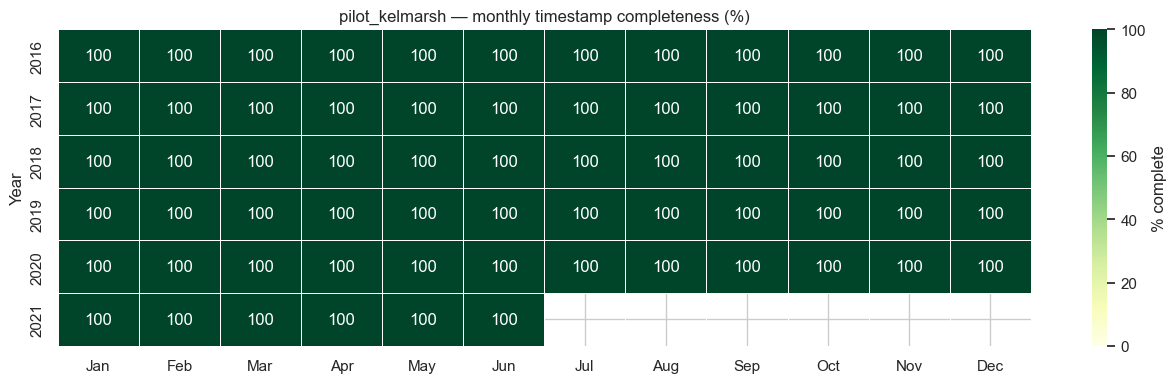

In [22]:
# ── Monthly completeness heatmap (rows = year, cols = month) ──────────────
for name, df in farms.items():
    idx = df.index
    freq = pd.infer_freq(idx[:200]) or 'h'
    expected_per_month = pd.date_range(idx[0], idx[-1], freq=freq).to_frame()
    expected_per_month['year']  = expected_per_month[0].dt.year
    expected_per_month['month'] = expected_per_month[0].dt.month
    exp_counts = expected_per_month.groupby(['year', 'month']).size()

    actual = pd.DataFrame({'ts': idx})
    actual['year']  = actual['ts'].dt.year
    actual['month'] = actual['ts'].dt.month
    act_counts = actual.groupby(['year', 'month']).size()

    completeness = (act_counts / exp_counts * 100).clip(upper=100).unstack('month')
    completeness.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'][:completeness.shape[1]]

    fig, ax = plt.subplots(figsize=(13, max(3, len(completeness) * 0.5 + 1)))
    sns.heatmap(
        completeness, ax=ax, cmap='YlGn', vmin=0, vmax=100,
        annot=True, fmt='.0f', linewidths=0.4, cbar_kws={'label': '% complete'},
    )
    ax.set_title(f'{name} — monthly timestamp completeness (%)')
    ax.set_ylabel('Year')
    plt.tight_layout()
    plt.show()

In [29]:
# ── All columns: dtype · missing · statistics ─────────────────────────────
for name, df in farms.items():
    print(f'=== {name} — column summary ===')
    summary = pd.DataFrame({
        'dtype'  : df.dtypes,
        'missing': df.isnull().sum(),
        'missing%': (df.isnull().mean() * 100).round(2),
    })
    stats = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3)
    summary = summary.join(stats, how='left')
    display(summary)
    print(df.head(50))

=== pilot_kelmarsh — column summary ===


,dtype,missing,missing%,mean,std,min,25%,50%,75%,max
energy_00_10,float64,0,0.0,3583.228,3562.864,0.000,750.000,2346.000,5418.000,22818.000
energy_10_20,float64,0,0.0,3562.934,3562.797,0.000,744.000,2328.000,5370.000,26424.000
energy_20_30,float64,0,0.0,3558.605,3526.417,0.000,739.190,2352.000,5400.000,22908.000
energy_30_40,float64,0,0.0,3584.307,3566.909,0.000,744.000,2346.000,5454.000,23232.000
energy_40_50,float64,0,0.0,3567.583,3564.231,0.000,747.500,2328.000,5403.000,26676.000
energy_50_60,float64,0,0.0,3558.917,3520.474,0.000,750.000,2358.000,5394.000,23532.000
energy_total,float64,0,0.0,21415.575,20861.922,0.000,4788.000,14341.500,32506.500,144498.000
2d,float64,0,0.0,279.427,5.000,259.974,275.721,279.521,283.193,293.415
2t,float64,0,0.0,282.943,5.994,266.492,278.449,282.578,287.237,305.972
10v,float64,0,0.0,0.728,3.275,-10.529,-1.680,0.686,2.917,12.964


                     energy_00_10  energy_10_20  energy_20_30  energy_30_40  \
production_time                                                               
2016-01-03 00:00:00           0.0           0.0           0.0           0.0   
2016-01-03 01:00:00           0.0           0.0           0.0           0.0   
2016-01-03 02:00:00           0.0           0.0           0.0           0.0   
2016-01-03 03:00:00           0.0           0.0           0.0           0.0   
2016-01-03 04:00:00           0.0           0.0           0.0           0.0   
2016-01-03 05:00:00           0.0           0.0           0.0           0.0   
2016-01-03 06:00:00           0.0           0.0           0.0           0.0   
2016-01-03 07:00:00           0.0           0.0           0.0           0.0   
2016-01-03 08:00:00           0.0           0.0           0.0           0.0   
2016-01-03 09:00:00           0.0           0.0           0.0           0.0   
2016-01-03 10:00:00           0.0           0.0     

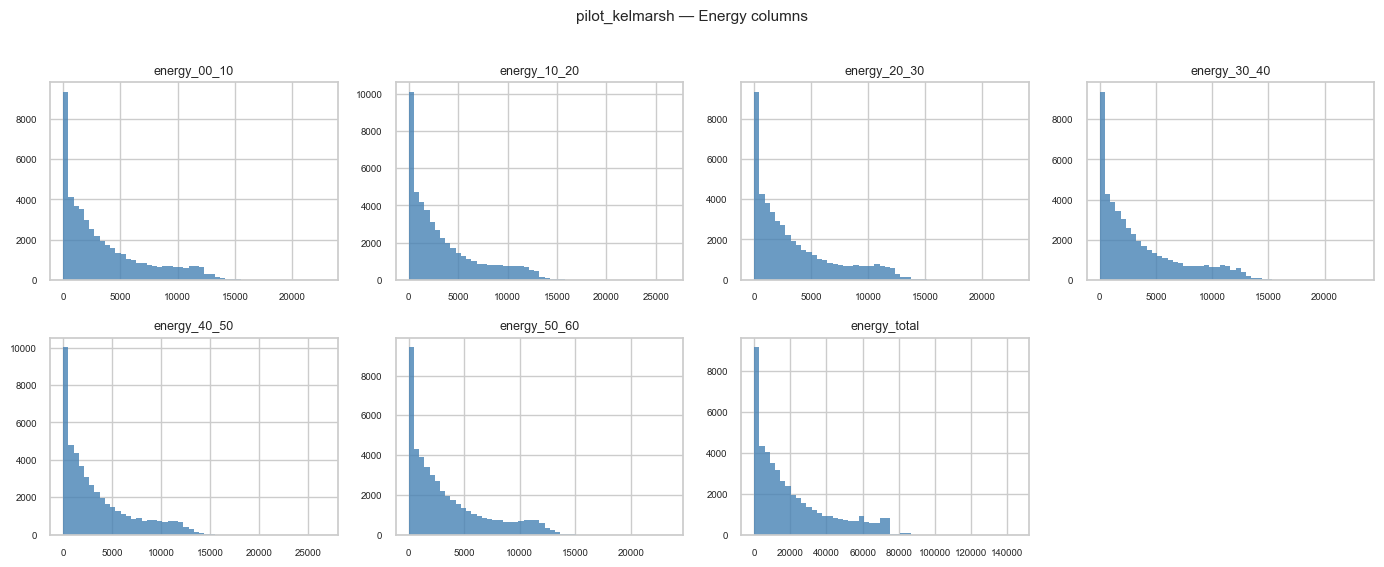

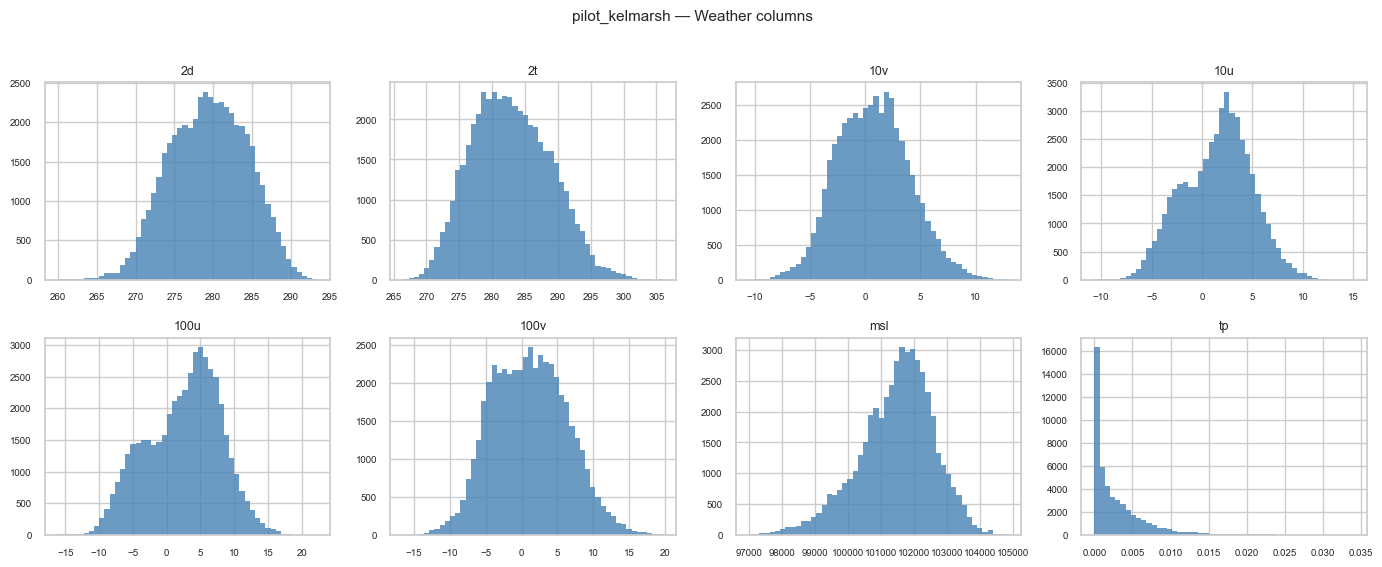

In [24]:
# ── Distribution of every column, grouped by type ─────────────────────────
farm_name = list(farms)[0]
df = farms[farm_name]

energy_cols  = sorted([c for c in df.columns if 'energy' in c.lower()])
weather_cols = [c for c in df.columns if c not in energy_cols]

def _plot_distributions(cols, title, ncols=4):
    if not cols:
        return
    nrows = -(-len(cols) // ncols)          # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(f'{farm_name} — {title}', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

_plot_distributions(energy_cols,  'Energy columns')
_plot_distributions(weather_cols, 'Weather columns')

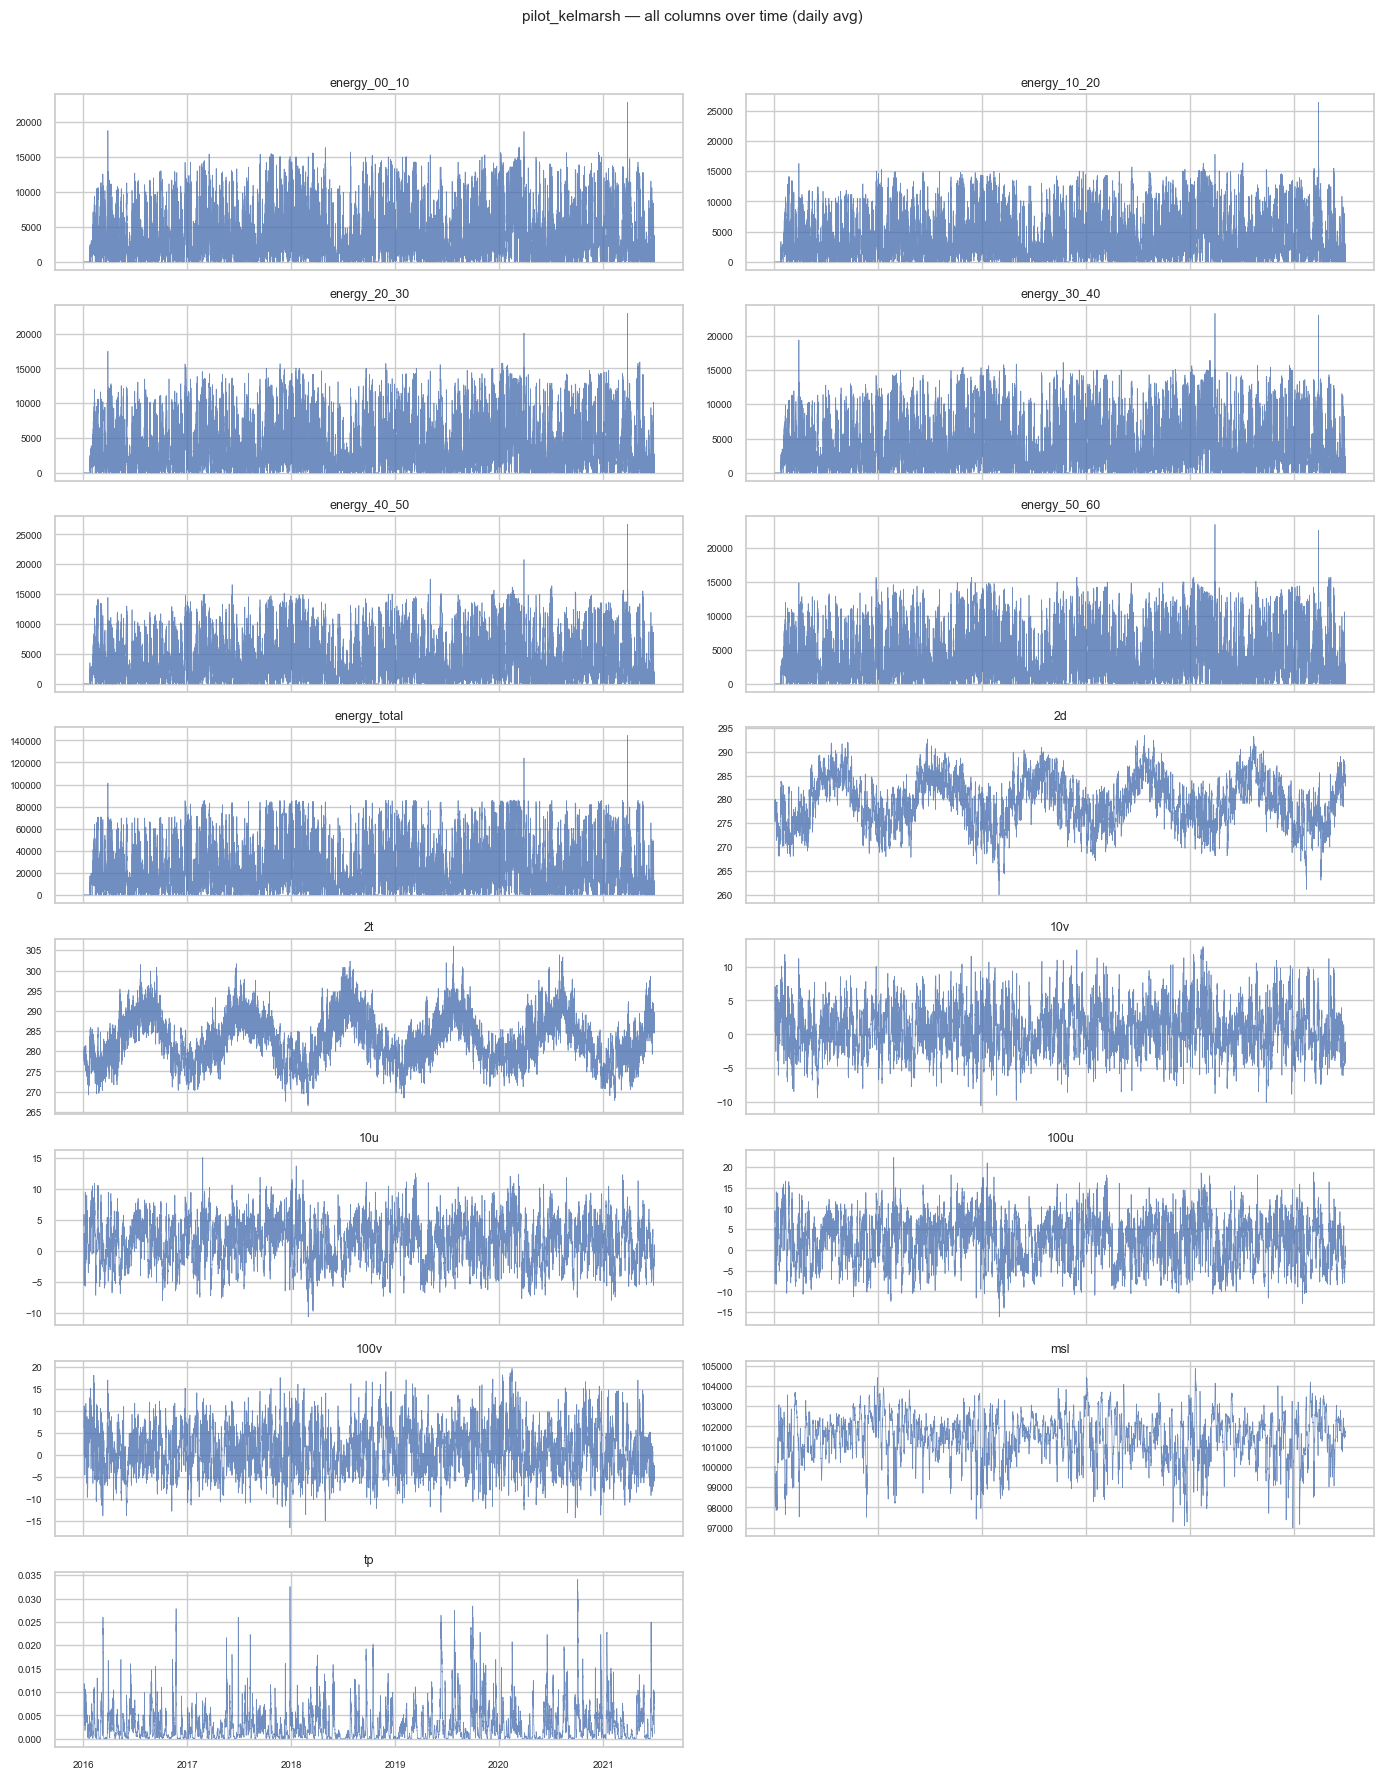

In [25]:
# ── Time series: all columns in a grid ────────────────────────────────────
all_cols = energy_cols + weather_cols
ncols = 2
nrows = -(-len(all_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.2), sharex=True)
axes = axes.flatten()

# sample down for speed if large
_df = df if len(df) <= 50_000 else df.resample('1D').mean()

for ax, col in zip(axes, all_cols):
    ax.plot(_df.index, _df[col], linewidth=0.5, alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('')

for ax in axes[len(all_cols):]:
    ax.set_visible(False)

fig.suptitle(f'{farm_name} — all columns over time (daily avg)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

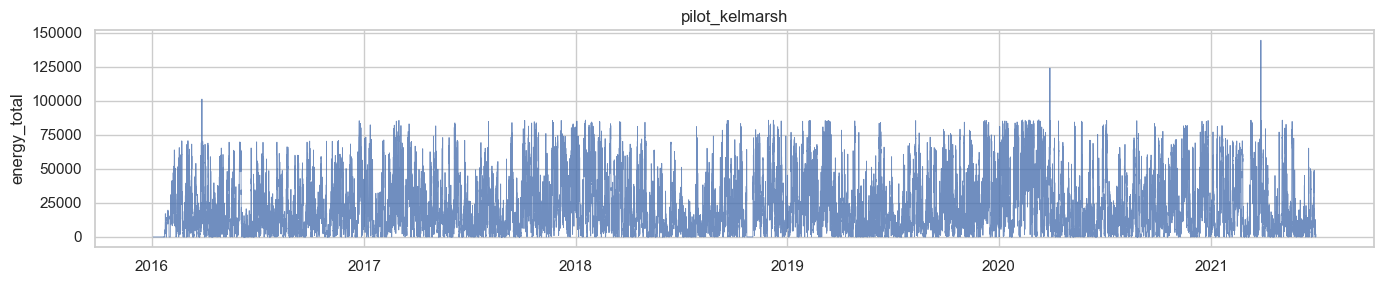

In [26]:
# ── Target time series ─────────────────────────────────────────────────────
n = len(farms)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, farms.items()):
    ax.plot(df.index, df[TARGET_COL], linewidth=0.6, alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel(TARGET_COL)

plt.tight_layout()
plt.show()

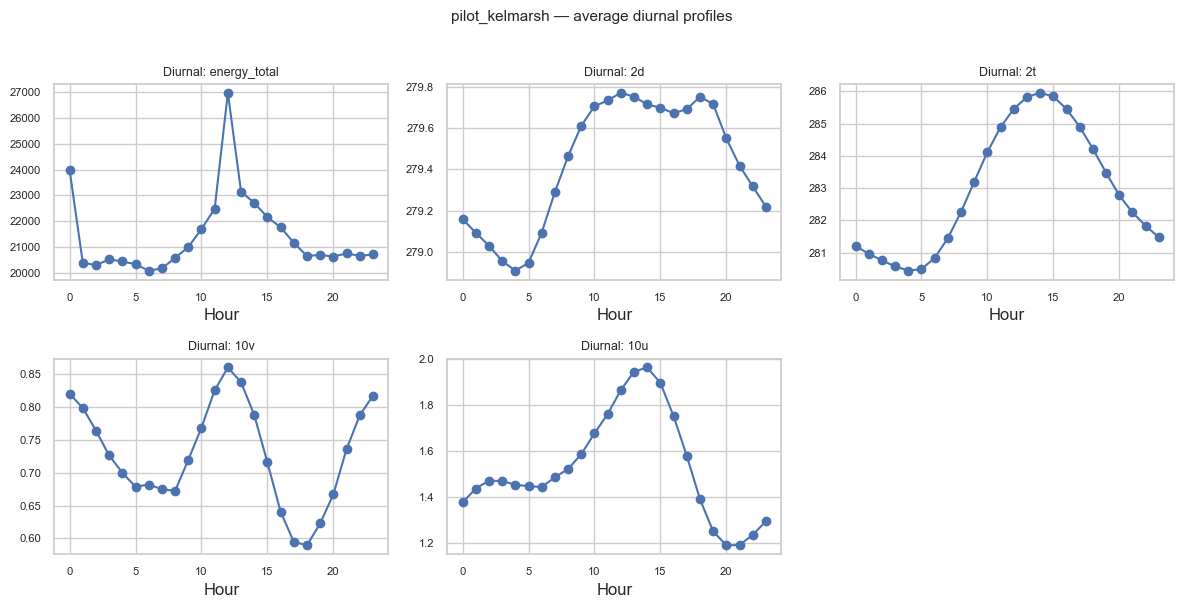

In [27]:
# ── Diurnal profile for target and key weather features ───────────────────
plot_cols = [TARGET_COL] + [c for c in weather_cols if c in df.columns][:4]
ncols = min(len(plot_cols), 3)
nrows = -(-len(plot_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, col in zip(axes, plot_cols):
    hourly = df[col].groupby(df.index.hour).mean()
    ax.plot(hourly.index, hourly.values, marker='o', linewidth=1.5)
    ax.set_title(f'Diurnal: {col}', fontsize=9)
    ax.set_xlabel('Hour')
    ax.tick_params(labelsize=8)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle(f'{farm_name} — average diurnal profiles', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

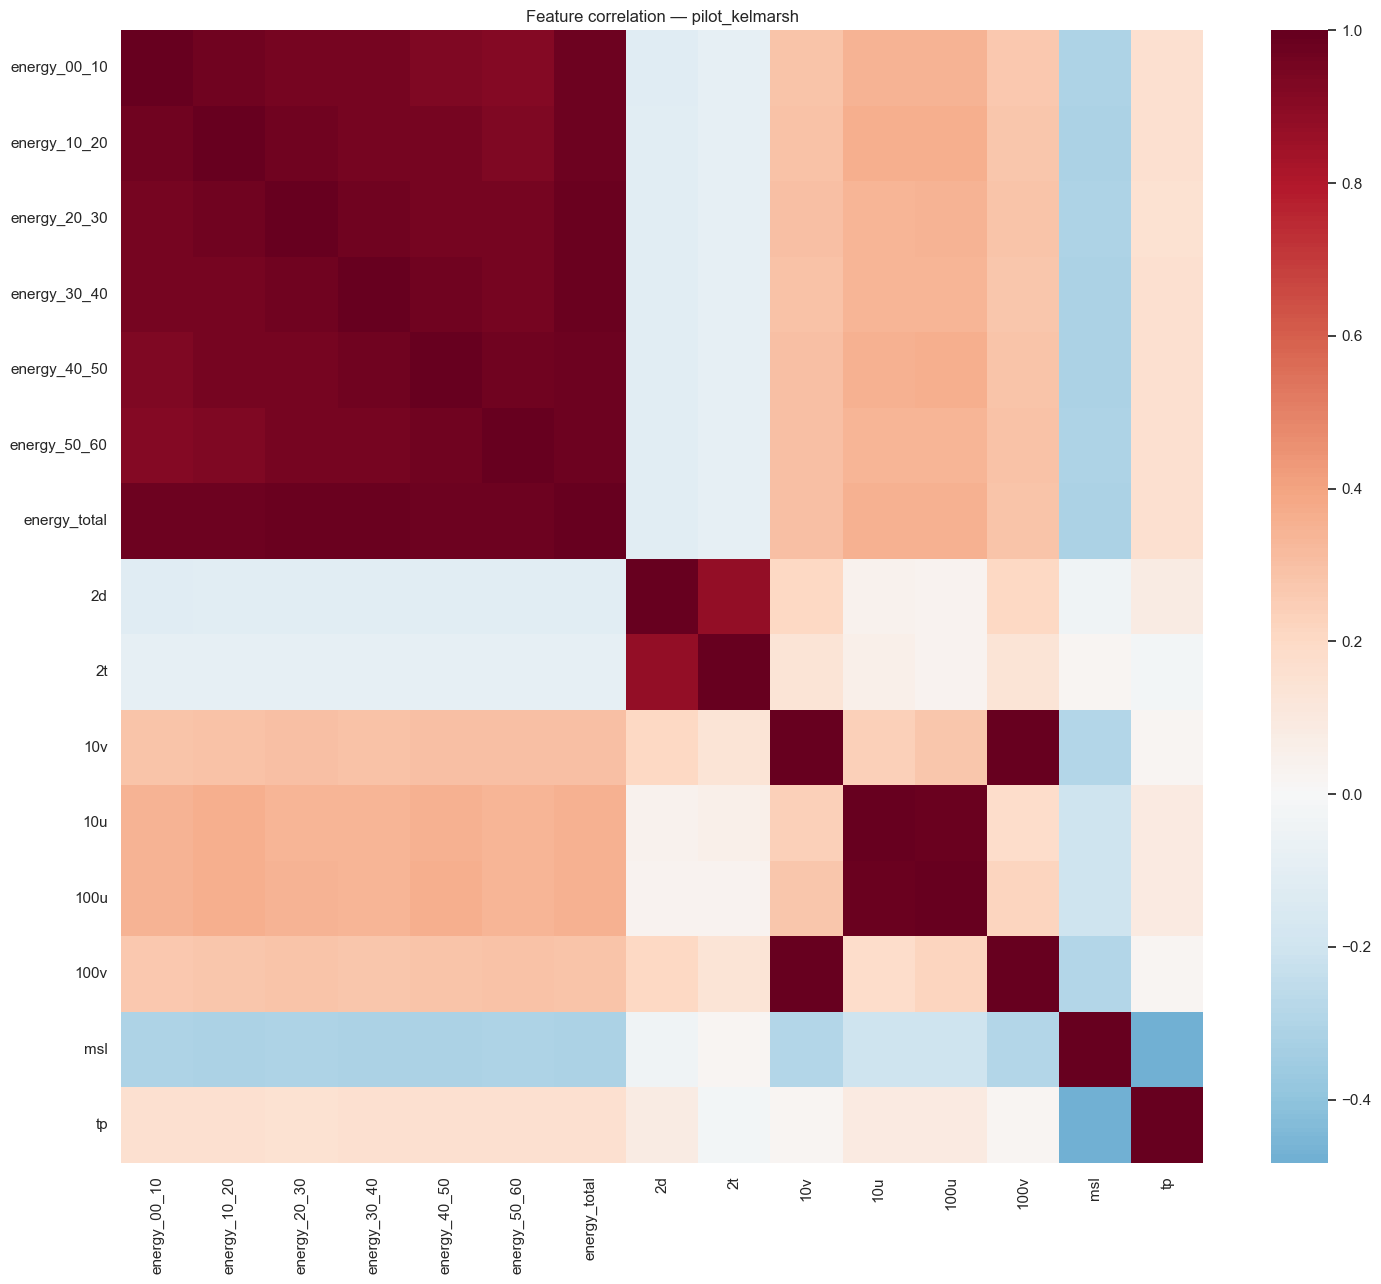

In [28]:
# Correlation heatmap for one farm (change name as needed)
farm_name = list(farms)[0]
df = farms[farm_name]

corr = df.corr()
fig, ax = plt.subplots(figsize=(max(8, len(corr)), max(6, len(corr) - 2)))
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, fmt='.2f', annot=len(corr) < 15)
ax.set_title(f'Feature correlation — {farm_name}')
plt.tight_layout()
plt.show()